<a href="https://colab.research.google.com/github/GimenesPaula/GimenesPaula/blob/main/Conhe%C3%A7a_o_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# Importando as bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import f_oneway
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from google.colab import files  # Para upload de arquivos no Colab
from patsy import dmatrices  # Para criar fórmulas com interações

In [2]:
# Configurando o estilo dos gráficos
sns.set(style="whitegrid")

# Upload do arquivo
print("Por favor, faça o upload da planilha contendo os dados do experimento (formato .csv ou .xlsx).")
uploaded = files.upload()  # Permite o upload do arquivo

# Identificando o arquivo carregado
for filename in uploaded.keys():
    print(f"Arquivo carregado: {filename}")

# Verificando o formato do arquivo e carregando os dados
if filename.endswith('.csv'):
    df = pd.read_csv(filename)
elif filename.endswith('.xlsx'):
    df = pd.read_excel(filename)
else:
    raise ValueError("Formato de arquivo não suportado. Por favor, use .csv ou .xlsx.")

# Verificando as colunas disponíveis
print("\nColunas disponíveis no arquivo:")
print(df.columns)

Por favor, faça o upload da planilha contendo os dados do experimento (formato .csv ou .xlsx).


Saving Brilho Inteiro.xlsx to Brilho Inteiro.xlsx
Arquivo carregado: Brilho Inteiro.xlsx

Colunas disponíveis no arquivo:
Index(['Produto', 'Formato', 'Conc', 'Antes_Depois', 'BNT', 'ReichRobbins',
       'Guiolet', 'Spec_Int', 'Spec_Theta', 'Spec_W_visual', 'Spec_Max',
       'Spec_Center', 'Shine_Int', 'Shine_Theta', 'Shine_Max', 'Shine_Center',
       'Chroma_Int', 'Chroma_Theta', 'Chroma_Max', 'Chroma_Center', 'Diff_Int',
       'Diff_Max', 'Overlapping', 'Shine_Visibility', 'Chroma_Visibility'],
      dtype='object')


In [3]:
# Solicitando ao usuário a seleção de colunas
colunas_selecionadas = input("\nDigite as colunas que deseja analisar (separadas por vírgula)\nou 'Todas' para analisar todas: ").strip()

if colunas_selecionadas.lower() == "todas":
    colunas_selecionadas = df.columns.tolist()
else:
    colunas_selecionadas = [col.strip() for col in colunas_selecionadas.split(",")]

# Verificando se as colunas selecionadas existem no DataFrame
for coluna in colunas_selecionadas:
    if coluna not in df.columns:
        raise ValueError(f"A coluna '{coluna}' não foi encontrada no arquivo.")



Digite as colunas que deseja analisar (separadas por vírgula)
ou 'Todas' para analisar todas: Shine_Visibility, Chroma_Visibility


In [4]:
# Solicitando ao usuário a quantidade de fatores e respostas
num_fatores = int(input("\nQuantos fatores você deseja analisar? "))

# Assumindo que os fatores estão nas primeiras colunas e as respostas nas colunas seguintes
fatores = df.columns[:num_fatores].tolist()
respostas = colunas_selecionadas

# Exibindo os fatores e respostas identificados
print("\nFatores identificados:", fatores)
print("Respostas identificadas:", respostas)



Quantos fatores você deseja analisar? 4

Fatores identificados: ['Produto', 'Formato', 'Conc', 'Antes_Depois']
Respostas identificadas: ['Shine_Visibility', 'Chroma_Visibility']


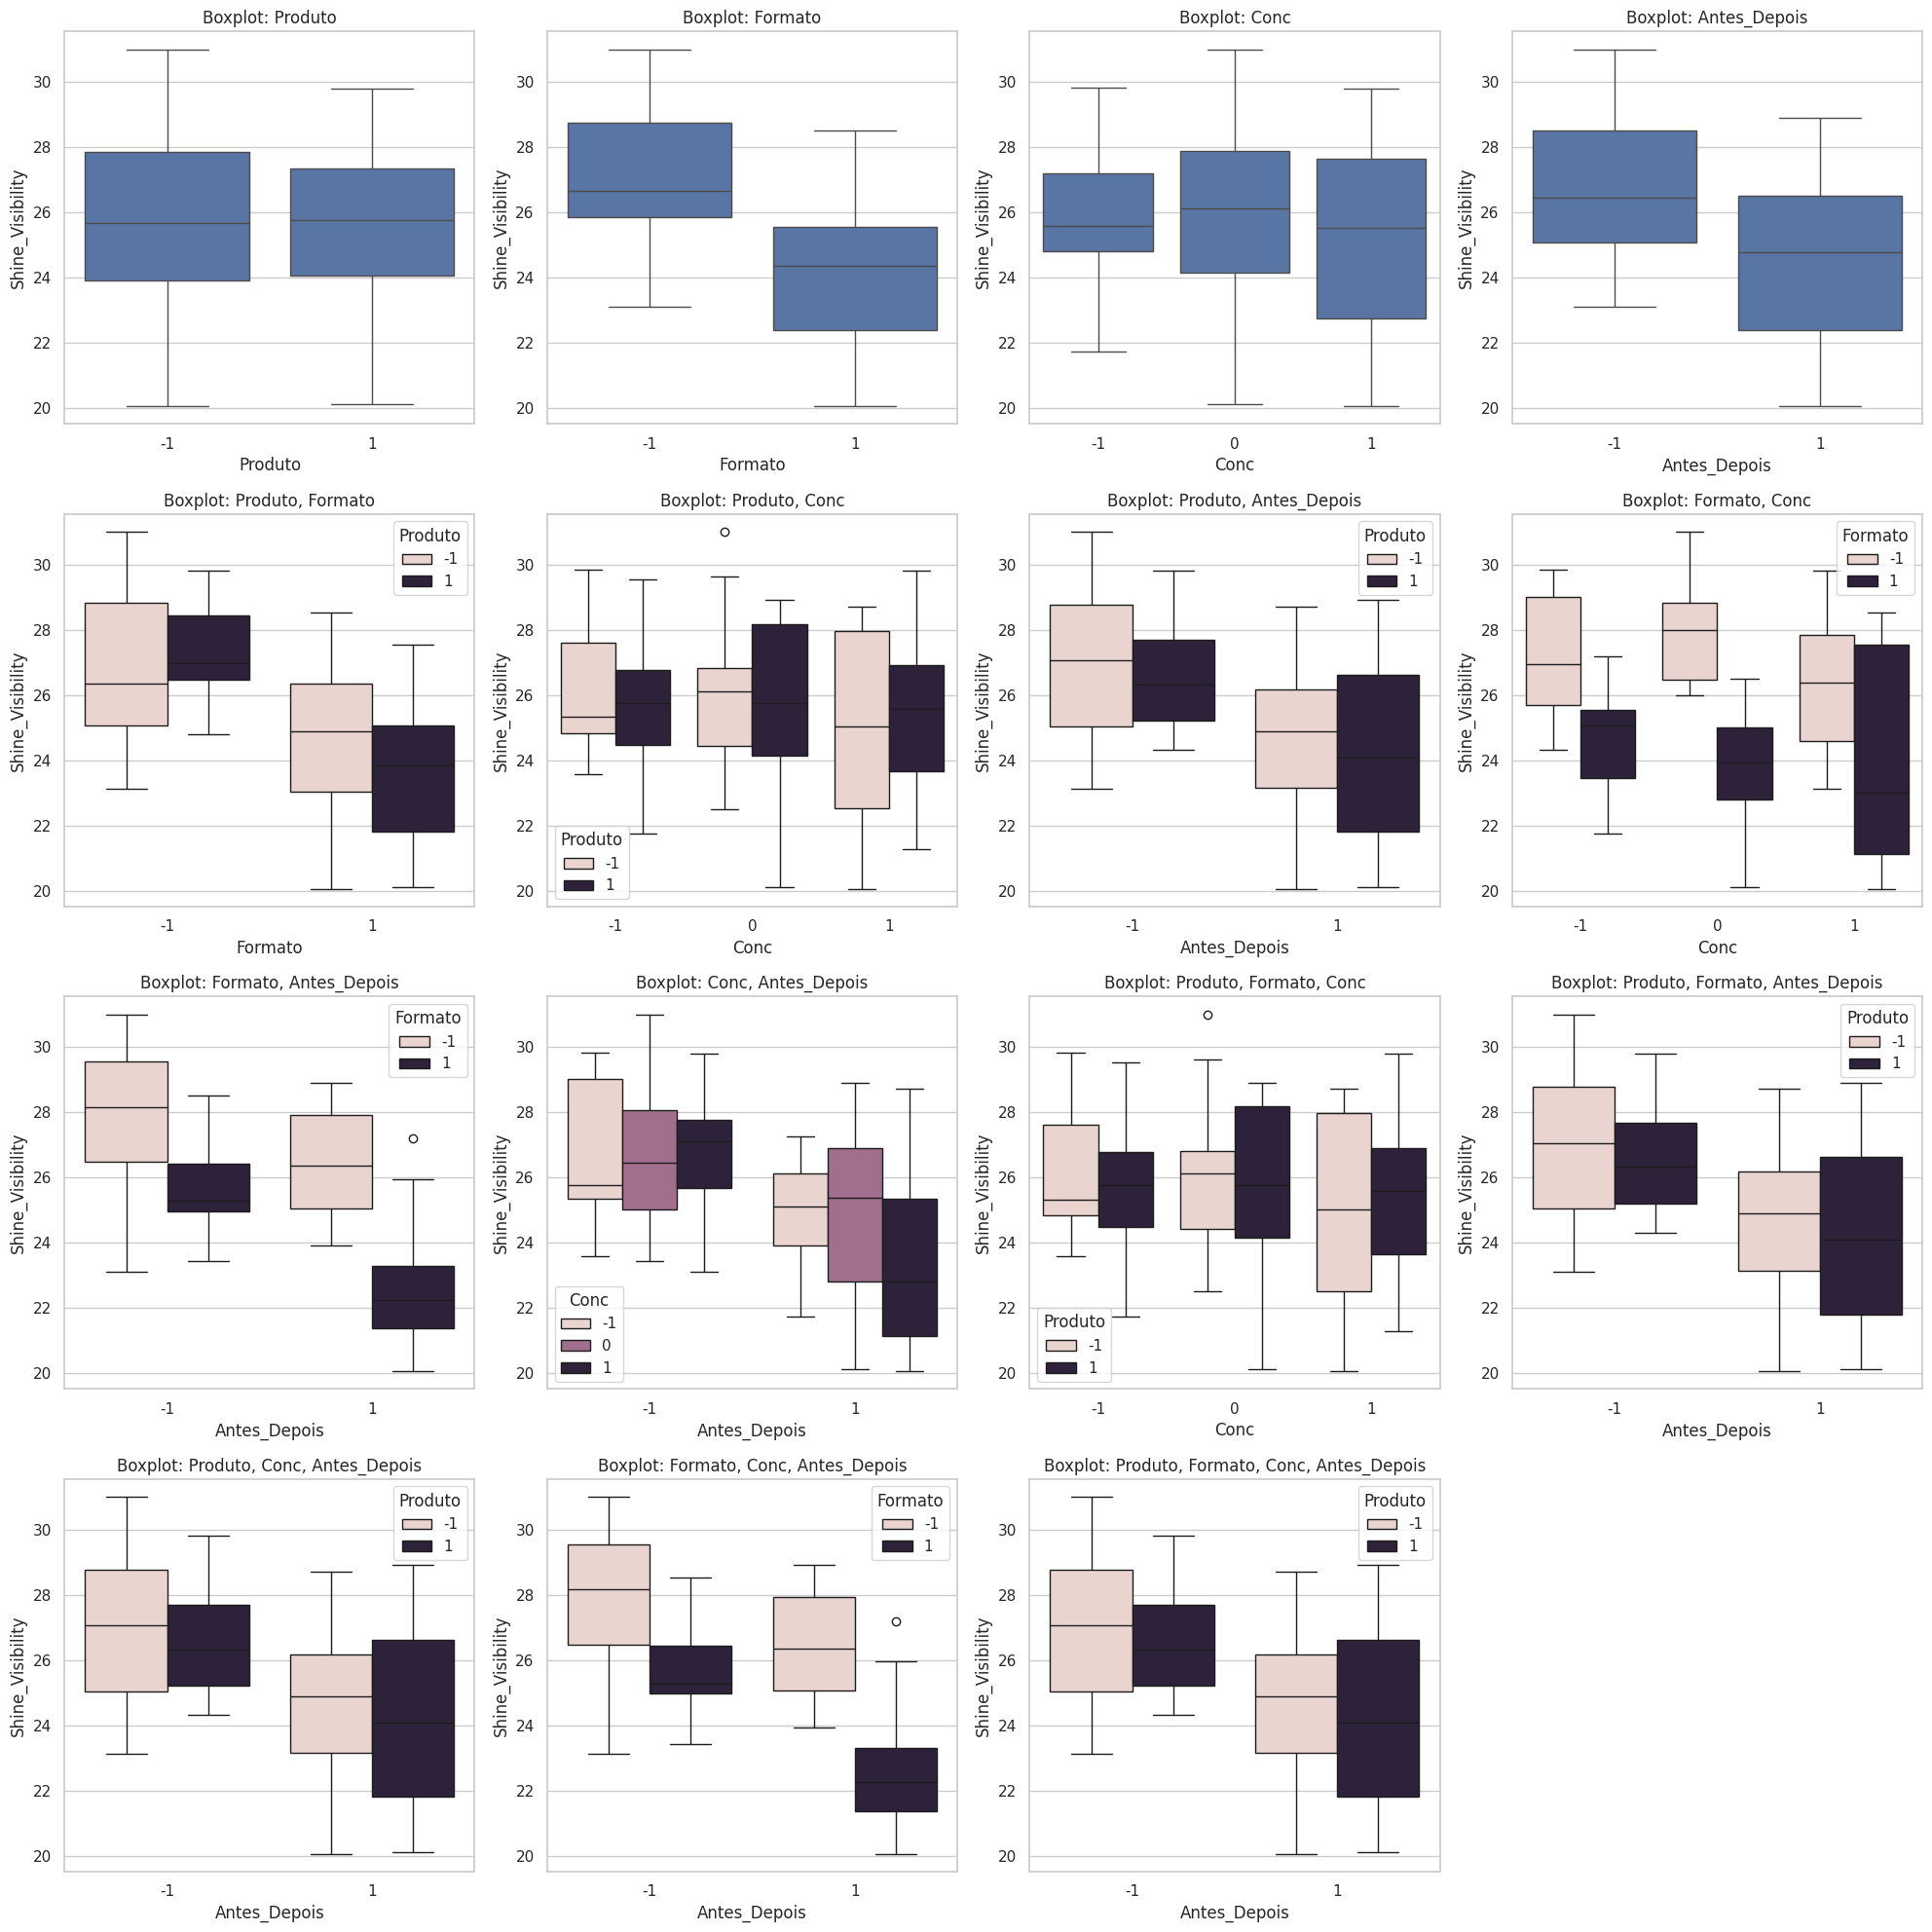

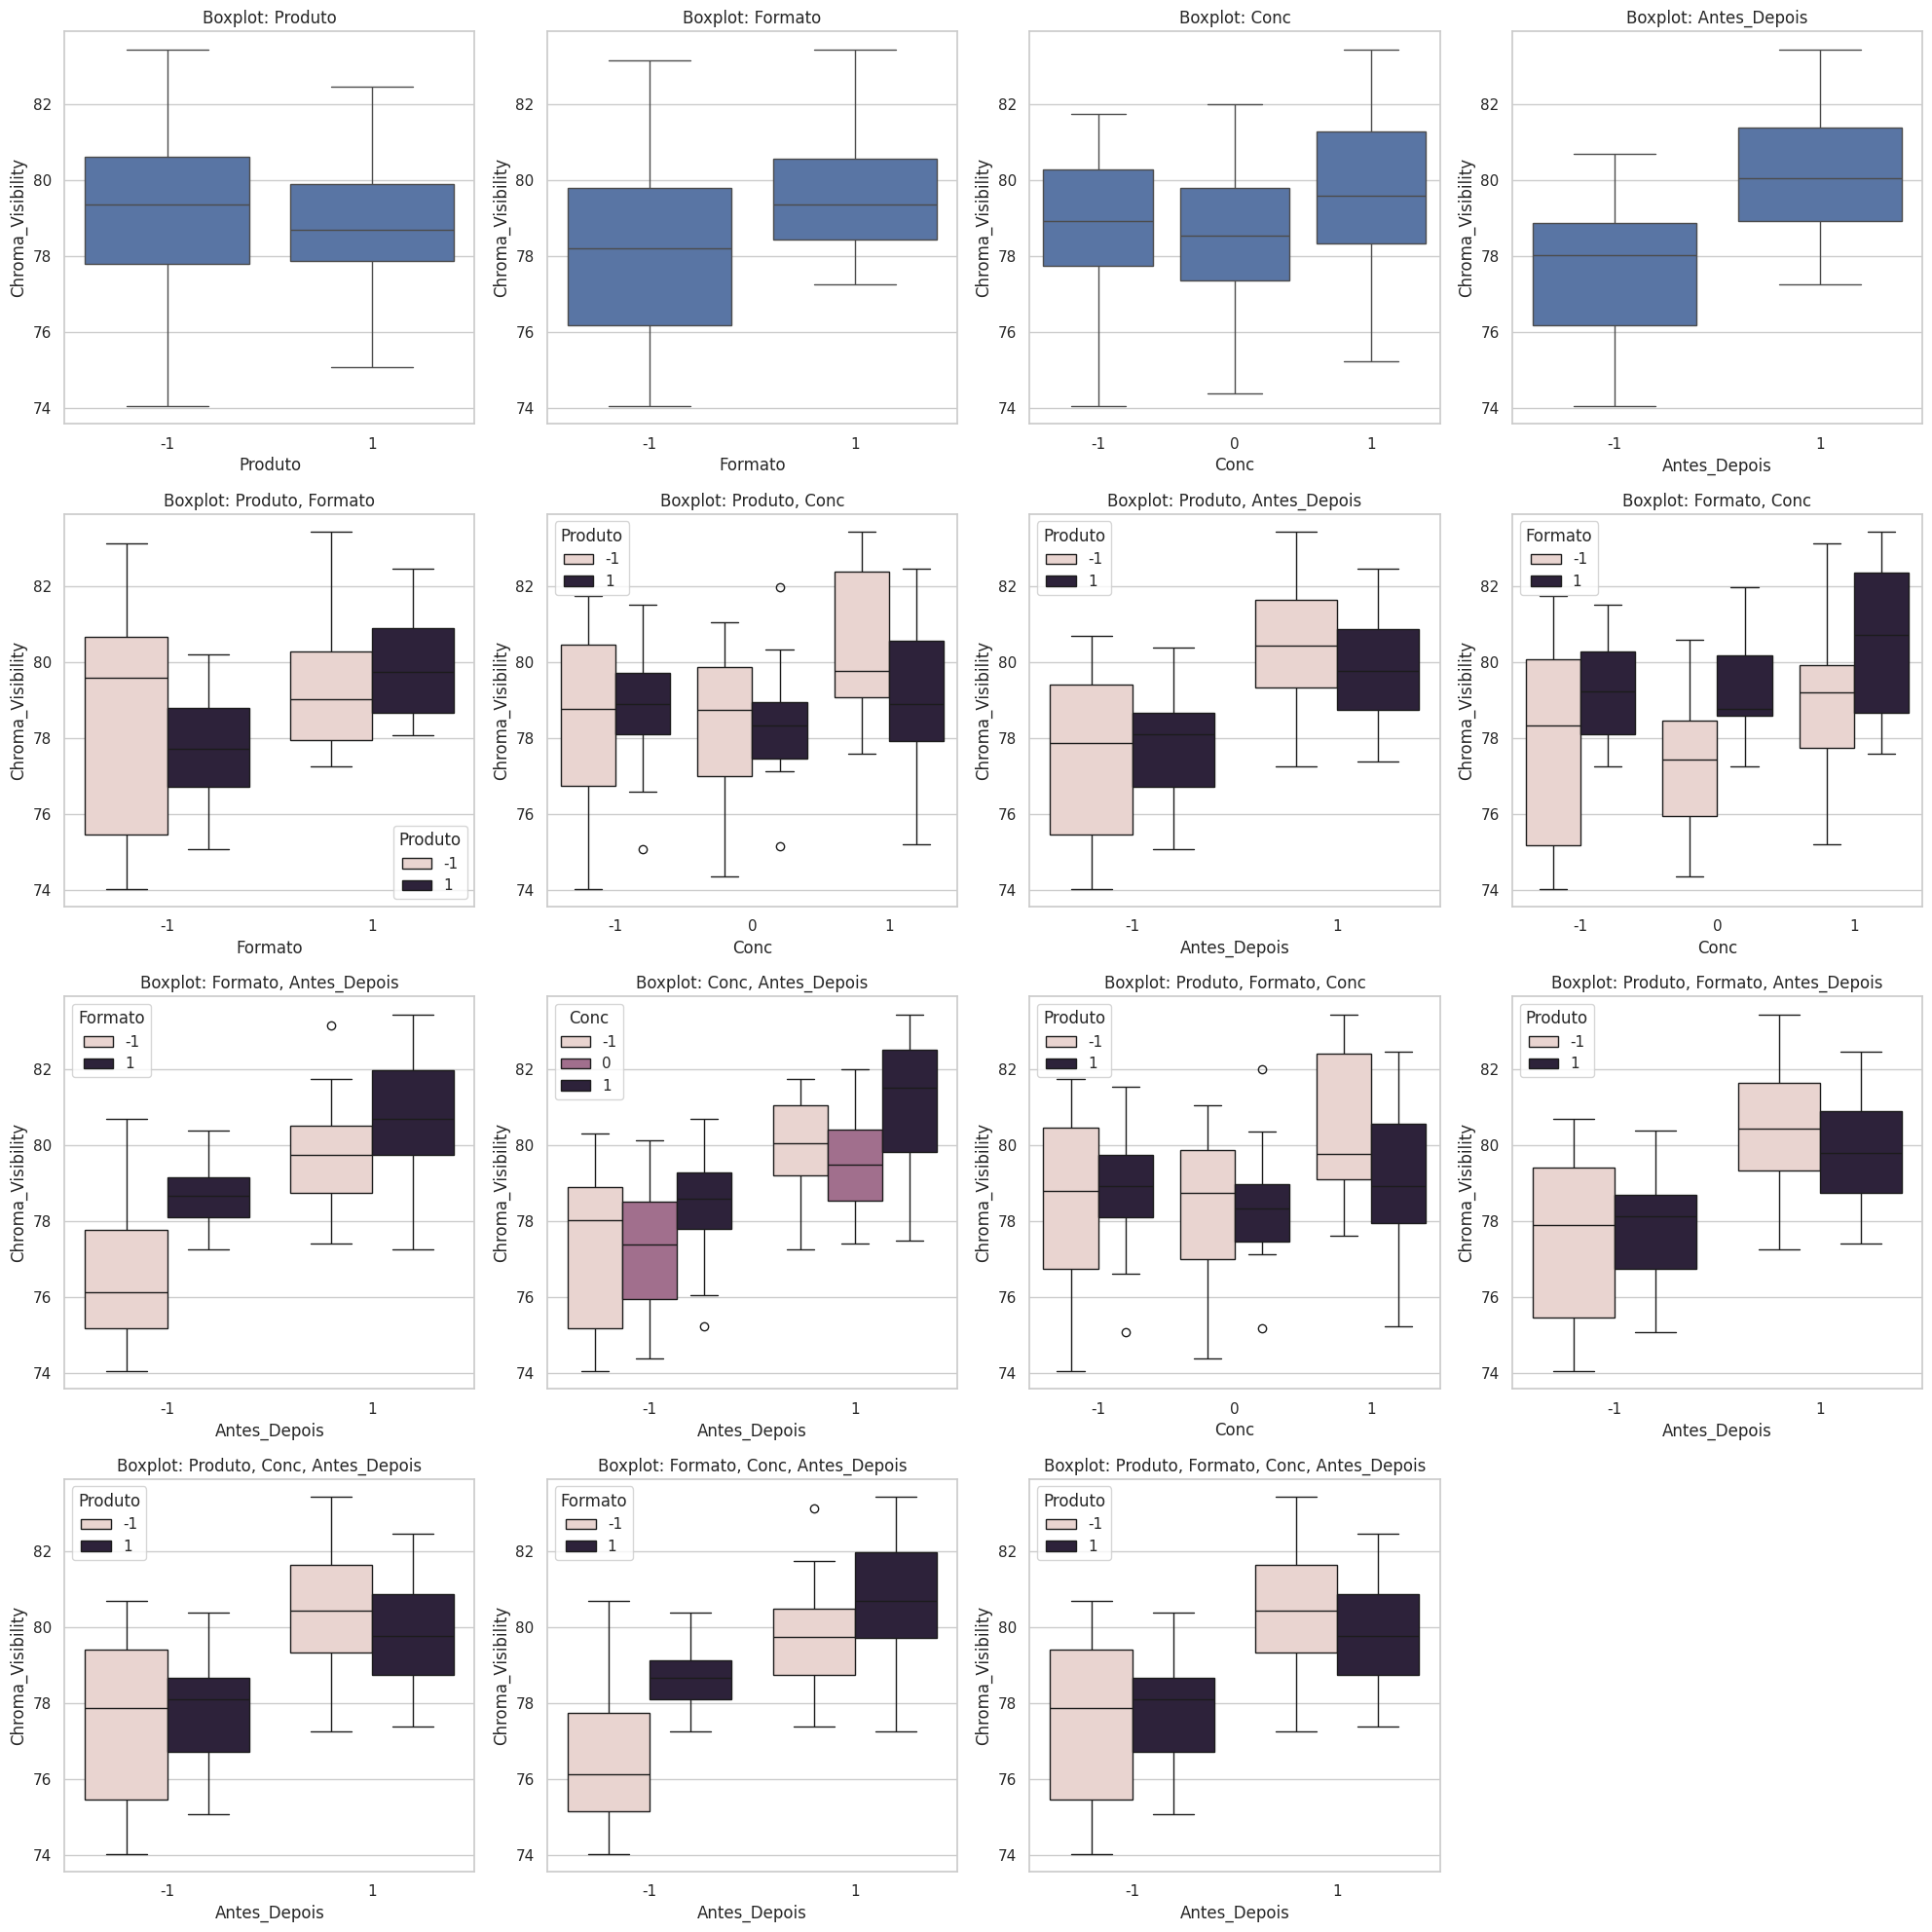

In [5]:
for resposta in respostas:
    # Gerar todas as combinações possíveis de fatores
    fator_combinacoes = []
    for r in range(1, len(fatores) + 1):  # Combinações de 1 fator até n fatores
        fator_combinacoes.extend(combinations(fatores, r))

    # Configuração da grade de gráficos
    num_graficos = len(fator_combinacoes)
    colunas = 4  # Número de gráficos por linha
    linhas = (num_graficos + colunas - 1) // colunas  # Calcula o número de linhas necessárias

    fig, axes = plt.subplots(linhas, colunas, figsize=(20, 5 * linhas))
    axes = axes.flatten()  # Achata a grade para facilitar o acesso aos eixos

    # Loop para gerar gráficos para cada combinação de fatores
    for i, combinacao in enumerate(fator_combinacoes):
        ax = axes[i]
        combinacao = list(combinacao)

        # Boxplot para a combinação de fatores
        sns.boxplot(data=df, x=combinacao[-1], y=resposta, hue=combinacao[0] if len(combinacao) > 1 else None, ax=ax)
        ax.set_title(f"Boxplot: {', '.join(combinacao)}")
        ax.set_xlabel(combinacao[-1])
        ax.set_ylabel(resposta)

    # Remover eixos vazios (se o número de gráficos for menor que o número de subplots)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [13]:
# Função para interpretar significância estatística
def interpretar_significancia(p_valor):
    if p_valor < 0.01:
        return "Significativo no nível de 99%"
    elif p_valor < 0.05:
        return "Significativo no nível de 95%"
    elif p_valor < 0.10:
        return "Significativo no nível de 90%"
    else:
        return "Não significativo"


In [21]:
# Testes estatísticos para todas as combinações de fatores
for resposta in respostas:
    print(f"\nTestes estatísticos para a resposta: {resposta}")

    # ANOVA para cada fator individualmente
    for fator in fatores:
        print(f"\nTeste ANOVA para o fator: {fator}")
        unique_niveis = df[fator].unique()
        anova_result = f_oneway(
            *[df[df[fator] == nivel][resposta] for nivel in unique_niveis]
        )
        print(f"F-valor: {anova_result.statistic:.2f}, p-valor: {anova_result.pvalue:.4f}")
        print(f"Interpretação: {interpretar_significancia(anova_result.pvalue)}")

    # ANOVA para todas as combinações de fatores (interações)
    for r in range(2, len(fatores) + 1):  # Começa com interações de 2 fatores
        for combinacao in combinations(fatores, r):
            print(f"\nTeste ANOVA para a combinação de fatores: {combinacao}")

            # Criar uma coluna de interação combinando os níveis dos fatores
            df['Interacao'] = df[list(combinacao)].apply(lambda row: '_'.join(row.values.astype(str)), axis=1)
            unique_interacoes = df['Interacao'].unique()

            # Realizar ANOVA para a interação
            anova_result = f_oneway(
                *[df[df['Interacao'] == nivel][resposta] for nivel in unique_interacoes]
            )
            print(f"F-valor: {anova_result.statistic:.2f}, p-valor: {anova_result.pvalue:.4f}")
            print(f"Interpretação: {interpretar_significancia(anova_result.pvalue)}")

    # Remover a coluna de interação após o cálculo
    if 'Interacao' in df.columns:
        df.drop(columns=['Interacao'], inplace=True)


Testes estatísticos para a resposta: Shine_Visibility

Teste ANOVA para o fator: Produto
F-valor: 0.14, p-valor: 0.7061
Interpretação: Não significativo

Teste ANOVA para o fator: Formato
F-valor: 34.37, p-valor: 0.0000
Interpretação: Significativo no nível de 99%

Teste ANOVA para o fator: Conc
F-valor: 0.64, p-valor: 0.5314
Interpretação: Não significativo

Teste ANOVA para o fator: Antes_Depois
F-valor: 15.70, p-valor: 0.0002
Interpretação: Significativo no nível de 99%

Teste ANOVA para a combinação de fatores: ('Produto', 'Formato')
F-valor: 12.05, p-valor: 0.0000
Interpretação: Significativo no nível de 99%

Teste ANOVA para a combinação de fatores: ('Produto', 'Conc')
F-valor: 0.35, p-valor: 0.8780
Interpretação: Não significativo

Teste ANOVA para a combinação de fatores: ('Produto', 'Antes_Depois')
F-valor: 5.15, p-valor: 0.0029
Interpretação: Significativo no nível de 99%

Teste ANOVA para a combinação de fatores: ('Formato', 'Conc')
F-valor: 7.83, p-valor: 0.0000
Interpreta

In [27]:
# Ajuste do modelo de regressão linear múltipla com interações até ordem n-1
for resposta in respostas:
    print(f"\nAjustando o modelo de regressão com interações até ordem n-1 para a resposta: {resposta}")

    # Criar a fórmula para o modelo com interações até ordem n-1
    # Exemplo: y ~ X1 + X2 + X3 + X1:X2 + X1:X3 + X2:X3 + X1:X2:X3
    interacoes = []
    for r in range(1, len(fatores)):  # Interações de ordem 1 até n-1
        interacoes.extend([":".join(comb) for comb in combinations(fatores, r)])
    formula = f"{resposta} ~ " + " + ".join(interacoes)

    # Criar as matrizes de design para o modelo
    y, X = dmatrices(formula, data=df, return_type='dataframe')

    # Ajustar o modelo
    modelo = sm.OLS(y, X).fit()

    # Exibir o resumo do modelo
    print(modelo.summary())

    # Filtrar os coeficientes significativos
    significativos = modelo.pvalues[modelo.pvalues < 0.05].index  # Apenas p-valores < 0.05
    print("\nFatores e interações significativos:")
    print(significativos)

    # Criar a equação do modelo apenas com os termos significativos
    coeficientes = modelo.params[significativos]
    equacao = "y = " + " + ".join([f"({coef:.4f} * {var})" for var, coef in coeficientes.items()])
    print("\nEquação do modelo (apenas termos significativos):")
    print(equacao)


Ajustando o modelo de regressão com interações até ordem n-1 para a resposta: Shine_Visibility
                            OLS Regression Results                            
Dep. Variable:       Shine_Visibility   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.618
Method:                 Least Squares   F-statistic:                     9.206
Date:                Thu, 15 May 2025   Prob (F-statistic):           4.22e-10
Time:                        16:09:28   Log-Likelihood:                -128.08
No. Observations:                  72   AIC:                             286.2
Df Residuals:                      57   BIC:                             320.3
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------